## Exploratory data analysis: PCA and Mahalanobis distance analysis

- **Principal Component Analysis (PCA)**: use PCA to reduce the dimensionality of the feature space. It will allow us to visualize the new data alongside the literature data within the same reduced feature space. PCA does this by transforming the original variables into a new set of uncorrelated variables (i.e., principal components), which are ordered by the amount of variance they can explain from the original data. This allows us to capture most of the information in the original data with fewer dimensions.

- **Uniform Manifold Approximation and Projection (UMAP)**: To better visualise the data in 2D space and perseve the global structure, we also employ UMAP, which is a nonlinear dimensionality reduction method. It excels in preserving the structure of high-dimensional data in low-dimensional space, making it suitable for visualizing clusters or groups within data. Unlike PCA, UMAP can capture nonlinear relationships within the data, making it more capable of separating different classes or clusters. Our UMAP application involves a Mahalanobis distance metric, which respects the covariance of the data, and the implementation scales the data and calculates the inverse covariance matrix as part of its workflow. This technique will further aid in visualizing and understanding the structure of our compositional feature space.

- **Mahalanobis Distance Analysis**: Following the visualization, we quantify how far the candidate compositions lie from the training domain by calculating squared Mahalanobis distances relative to the literature reference sets for corrosion and hardness separately. For each task, the literature dataset defines the reference mean and covariance, and both the literature samples and the newly predicted compositions are scored against that same reference distribution. We then convert the squared Mahalanobis distances into empirical tail probabilities using the empirical distribution of reference-set distances. These empirical tail probabilities serve as novelty scores, where smaller values indicate points that are more extreme relative to the training domain.


In [21]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import math
import matplotlib.cm as cm
import matplotlib as mpl
import os
import re
import random
import umap
import scipy.stats as stats
from scipy.stats import chi2
from scipy.linalg import inv
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.covariance import EmpiricalCovariance
from numba import set_num_threads
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
# mpl.rcParams['font.family'] = 'FreeSans'

# display the current working directory
display("Current working directory: {0}".format(os.getcwd()))

data_path = '../01_Dataset_Cleaned/'
display(os.path.isfile(data_path+'LiteratureDataset_Hardness_YW_v4_processed.xlsx'))

'Current working directory: /home/yuxiangw/Users/ywu153/2026-02_FORGE-CCA-Paper/CCA_CALPHAD_SSS_ML/CCA_representation_ML/02_Dataset_EDA_Feature_UMAP_Mahalanobis'

True

### Import hardness and corrosion LITERATURE datasets


In [22]:
# Define column names for the chemical composition data, specific testing conditions,
# selected features, and outputs for the Hardness and Corrosion datasets.
compo_column = ['Fe', 'Cr', 'Ni', 'Mo', 'W', 'N', 'Nb', 'C', 'Si',
                'Mn', 'Cu', 'Al', 'V', 'Ta', 'Ti', 'Co', 'Mg', 'Y', 'Zr', 'Hf']
C_specific_testing_column = ['TestTemperature_C',
                             'ChlorideIonConcentration', 'pH', 'ScanRate_mVs']
specific_features_sel_column = ['delta_a', 'Tm', 'sigma_Tm',
                                'Hmix', 'sigma_Hmix', 'sigma_elec_nega', 'VEC', 'sigma_VEC']
H_output_column = ['converted HV']
C_output_column = ['AvgPittingPotential_mV']

# Load the Hardness and Corrosion datasets.
df_H = pd.read_excel(
    data_path + 'LiteratureDataset_Hardness_YW_v4_processed.xlsx')
df_C = pd.read_excel(
    data_path + 'LiteratureDataset_Corrosion_YW_v4_processed.xlsx')

# Split the datasets into composition, specific features, and output data.
df_H_compo, df_H_specific_features, df_H_output = df_H[compo_column], df_H[
    specific_features_sel_column], df_H[H_output_column]
(df_C_compo, df_C_specific_testing,
 df_C_specific_features, df_C_output) = df_C[compo_column], df_C[C_specific_testing_column], df_C[specific_features_sel_column], df_C[C_output_column]

# Combine composition and selected feature data for the Hardness and Corrosion datasets.
df_H_compo_specific_features = pd.concat(
    [df_H_compo, df_H_specific_features], axis=1)
df_C_compo_specific_features = pd.concat(
    [df_C_compo, df_C_specific_features], axis=1)

### Import NEW dataset


In [23]:
# Composition columns for NiCrCoVFe and NiCrMoTiFe
NiCrCoVFe_compo_column = ['Ni', 'Cr', 'Co', 'V', 'Fe']
NiCrMoTiFe_compo_column = ['Ni', 'Cr', 'Mo', 'Ti', 'Fe']

# Load datasets
df_NiCrCoVFe = pd.read_excel(
    data_path + 'MultiTaskModel_NiCrCoVFe_KW99_wt_pct_processed.xlsx')
df_NiCrMoTiFe = pd.read_excel(
    data_path + 'MultiTaskModel_NiCrMoTiFe_KW131_wt_pct_processed.xlsx')

# Extract composition and feature data
df_NiCrCoVFe_compo, df_NiCrCoVFe_specific_features = df_NiCrCoVFe[
    NiCrCoVFe_compo_column], df_NiCrCoVFe[specific_features_sel_column]
df_NiCrMoTiFe_compo, df_NiCrMoTiFe_specific_features = df_NiCrMoTiFe[
    NiCrMoTiFe_compo_column], df_NiCrMoTiFe[specific_features_sel_column]

# Base composition dataframe
df_compo = pd.DataFrame(columns=compo_column)

# Align composition columns and fill missing values with 0
df_NiCrCoVFe_compo = pd.concat(
    [df_compo, df_NiCrCoVFe_compo], axis=0).fillna(0)
df_NiCrMoTiFe_compo = pd.concat(
    [df_compo, df_NiCrMoTiFe_compo], axis=0).fillna(0)

# Combine composition and feature data
df_NiCrCoVFe_compo_specific_features = pd.concat(
    [df_NiCrCoVFe_compo, df_NiCrCoVFe_specific_features], axis=1)
df_NiCrMoTiFe_compo_specific_features = pd.concat(
    [df_NiCrMoTiFe_compo, df_NiCrMoTiFe_specific_features], axis=1)

# Show the first row for verification
display(df_NiCrCoVFe_compo_specific_features.head(1))
display(df_NiCrMoTiFe_compo_specific_features.head(1))

,Fe,Cr,Ni,Mo,W,N,Nb,C,Si,Mn,...,Zr,Hf,delta_a,Tm,sigma_Tm,Hmix,sigma_Hmix,sigma_elec_nega,VEC,sigma_VEC
0,10.271486,31.290494,51.985556,0,0,0,0,0,0,0,...,0,0,0.007568,1898.775789,210.082957,-6.271299,2.111357,0.115683,8.311398,1.854884


,Fe,Cr,Ni,Mo,W,N,Nb,C,Si,Mn,...,Zr,Hf,delta_a,Tm,sigma_Tm,Hmix,sigma_Hmix,sigma_elec_nega,VEC,sigma_VEC
0,14.316994,35.210247,45.453038,4.138939,0,0,0,0,0,0,...,0,0,0.022535,1943.689937,257.662231,-6.600671,2.725195,0.129477,8.019565,1.882783


### Datasets labelling for both datasets and concatenation


In [24]:
# Add 'dataset' column to Corrosion, Hardness, and the two new dataframes
for df_compo, df_compo_specific_features, label in zip(
    [df_C_compo, df_H_compo, df_NiCrMoTiFe_compo, df_NiCrCoVFe_compo],
    [df_C_compo_specific_features, df_H_compo_specific_features,
        df_NiCrMoTiFe_compo_specific_features, df_NiCrCoVFe_compo_specific_features],
        ['corrosion dataset', 'hardness dataset', 'new NiCrMoTiFe data', 'new NiCrCoVFe data']):
    df_compo['dataset'] = label
    df_compo_specific_features['dataset'] = label

# Combine Corrosion and Hardness composition data into a single dataframe
df_compo_conc = pd.concat([df_C_compo, df_H_compo], ignore_index=True)
# df_compo_conc.to_csv('pairplot_corrosion_hardness_datasets.csv', index=False)
display(df_compo_conc.iloc[[0, -1]], df_compo_conc.shape)

# Add the new datasets to the combined composition dataframe
df_compo_conc_new = pd.concat(
    [df_compo_conc, df_NiCrMoTiFe_compo, df_NiCrCoVFe_compo], ignore_index=True)
display(df_compo_conc_new.iloc[[0, 712, -70, -1]], df_compo_conc_new.shape)

# Combine Corrosion and Hardness composition with specific features into a single dataframe
df_compo_specific_features_conc = pd.concat(
    [df_C_compo_specific_features, df_H_compo_specific_features], ignore_index=True)
display(df_compo_specific_features_conc.iloc[[
        0, -1]], df_compo_specific_features_conc.shape)

# Add the new datasets to the combined composition with specific features dataframe
df_compo_specific_features_conc_new = pd.concat(
    [df_compo_specific_features_conc, df_NiCrMoTiFe_compo_specific_features, df_NiCrCoVFe_compo_specific_features], ignore_index=True)
display(df_compo_specific_features_conc_new.iloc[[
        0, 712, -70, -1]], df_compo_specific_features_conc_new.shape)

/tmp/ipykernel_1489301/1185198076.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_compo['dataset'] = label
/tmp/ipykernel_1489301/1185198076.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_compo['dataset'] = label


,Fe,Cr,Ni,Mo,W,N,Nb,C,Si,Mn,...,Al,V,Ta,Ti,Co,Mg,Y,Zr,Hf,dataset
0,69.77,18.0,10.0,0.00,0.0,0.0,0.0,0.03,1.0,1.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,corrosion dataset
1391,20.17,0.0,42.4,6.93,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,9.2,0.0,0.0,21.29,0.0,0.0,0.0,0.0,hardness dataset


(1392, 21)

,Fe,Cr,Ni,Mo,W,N,Nb,C,Si,Mn,...,Al,V,Ta,Ti,Co,Mg,Y,Zr,Hf,dataset
0,69.770000,18.000000,10.000000,0.000000,0.0,0.0,0.0,0.03,1.0,1.00,...,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,corrosion dataset
712,19.920000,18.540000,20.930000,0.000000,0.0,0.0,0.0,0.00,0.0,19.59,...,0.0,0.000000,0.0,0.000000,21.02000,0.0,0.0,0.0,0.0,hardness dataset
1460,63.370312,5.076982,23.439965,4.034033,0.0,0.0,0.0,0.00,0.0,0.00,...,0.0,0.000000,0.0,4.078709,0.00000,0.0,0.0,0.0,0.0,new NiCrMoTiFe data
1529,51.347188,5.827793,31.584854,0.000000,0.0,0.0,0.0,0.00,0.0,0.00,...,0.0,8.142295,0.0,0.000000,3.09787,0.0,0.0,0.0,0.0,new NiCrCoVFe data


(1530, 21)

,Fe,Cr,Ni,Mo,W,N,Nb,C,Si,Mn,...,Hf,delta_a,Tm,sigma_Tm,Hmix,sigma_Hmix,sigma_elec_nega,VEC,sigma_VEC,dataset
0,69.77,18.0,10.0,0.00,0.0,0.0,0.0,0.03,1.0,1.0,...,0.0,0.019485,1869.874935,173.330067,-4.484751,4.974488,0.083927,7.719083,1.188494,corrosion dataset
1391,20.17,0.0,42.4,6.93,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.024620,1852.264411,257.734769,-6.826400,3.890390,0.103641,8.659625,1.614745,hardness dataset


(1392, 29)

,Fe,Cr,Ni,Mo,W,N,Nb,C,Si,Mn,...,Hf,delta_a,Tm,sigma_Tm,Hmix,sigma_Hmix,sigma_elec_nega,VEC,sigma_VEC,dataset
0,69.770000,18.000000,10.000000,0.000000,0.0,0.0,0.0,0.03,1.0,1.00,...,0.0,0.019485,1869.874935,173.330067,-4.484751,4.974488,0.083927,7.719083,1.188494,corrosion dataset
712,19.920000,18.540000,20.930000,0.000000,0.0,0.0,0.0,0.00,0.0,19.59,...,0.0,0.032693,1801.194406,214.312458,-4.159700,2.197442,0.138357,8.000092,1.414148,hardness dataset
1460,63.370312,5.076982,23.439965,4.034033,0.0,0.0,0.0,0.00,0.0,0.00,...,0.0,0.039801,1844.869218,192.175144,-5.701689,4.064609,0.098628,8.101491,1.410874,new NiCrMoTiFe data
1529,51.347188,5.827793,31.584854,0.000000,0.0,0.0,0.0,0.00,0.0,0.00,...,0.0,0.016731,1841.240483,148.982134,-5.437576,2.782294,0.086038,8.238582,1.496411,new NiCrCoVFe data


(1530, 29)

### Pairplots: the new datasets in relation to hardness and corrosion literatrue datasets

composition space


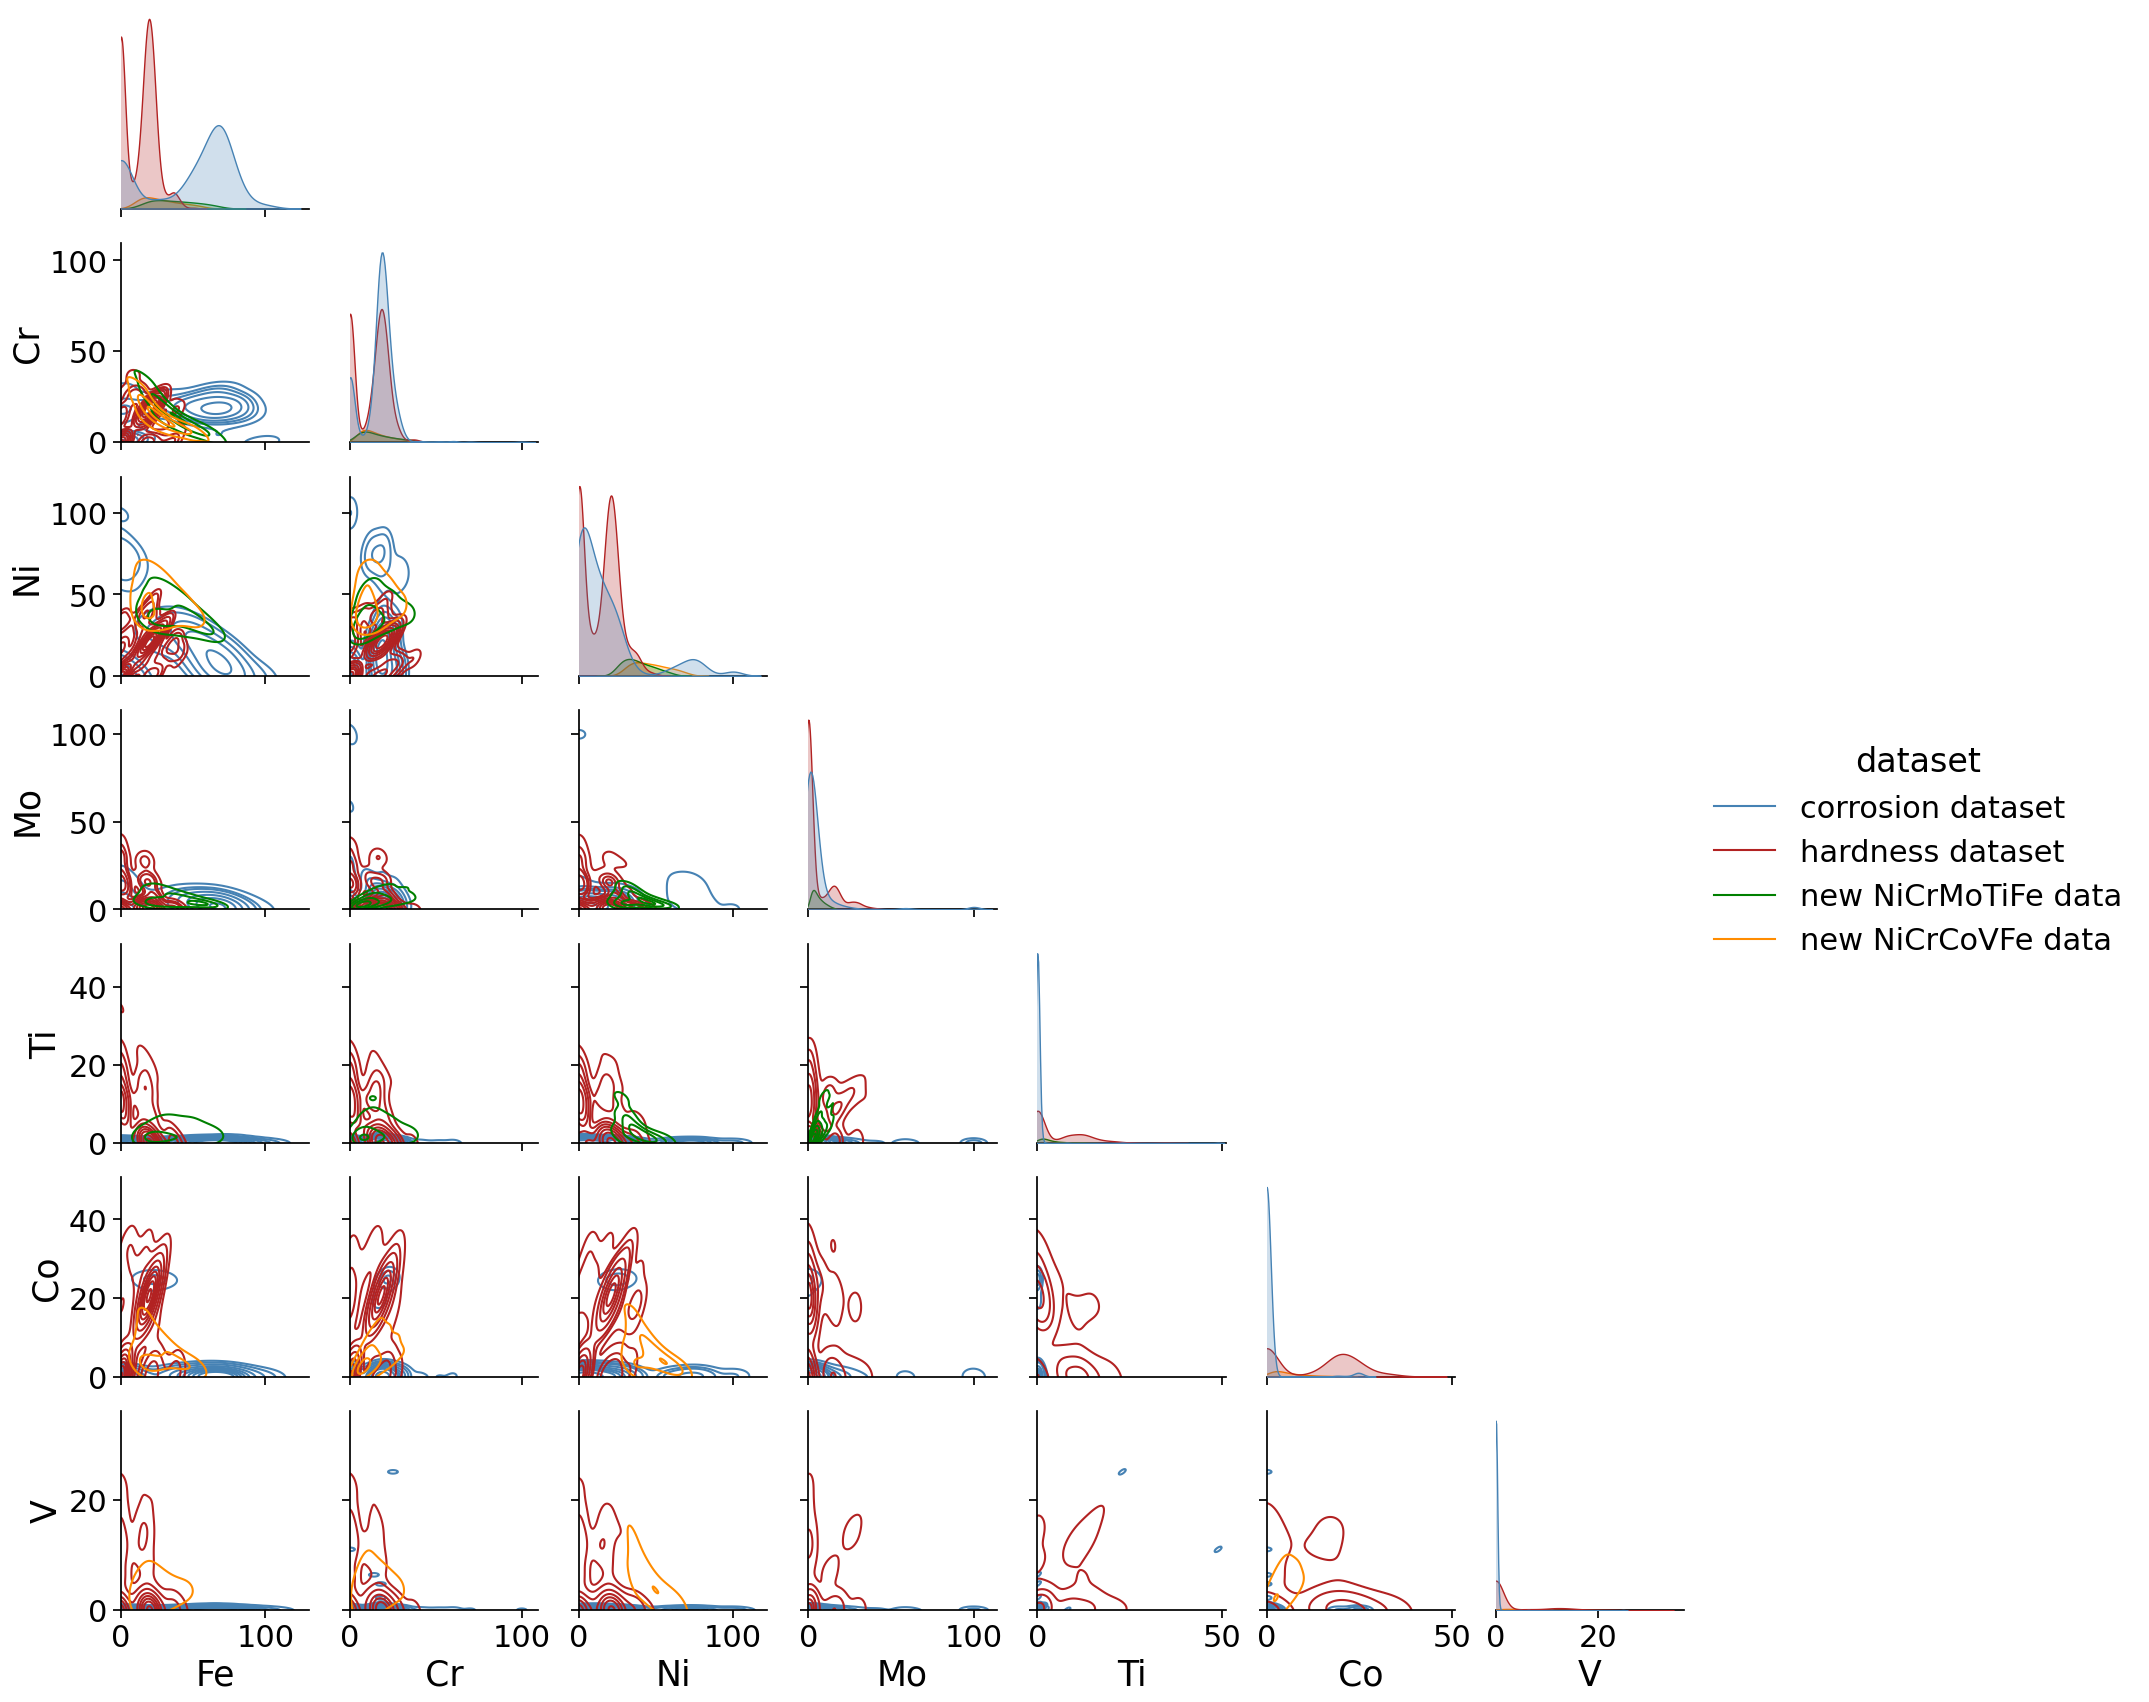

In [25]:
sns.set_context("notebook", font_scale=2)

# Define color palette for the pairplot
palette = ["steelblue", "firebrick", "green", "darkorange"]
# Create pairplot with KDE for all data
grid_kde = sns.pairplot(df_compo_conc_new, vars=['Fe', 'Cr', 'Ni', 'Mo', 'Ti', 'Co', 'V'],
                        hue="dataset", kind="kde", corner=True, palette=palette)

# Adjust x and y limits using list comprehension
_ = [[ax.set_xlim(left=0),
      ax.set_ylim(bottom=0),
      ax.xaxis.label.set_size(25),
      ax.yaxis.label.set_size(25)]
     for ax_row in grid_kde.axes for ax in ax_row if ax is not None]

plt.savefig('pairplot_compo_section_literature+new.pdf', bbox_inches='tight')

plt.show()

composition + engineered feature space


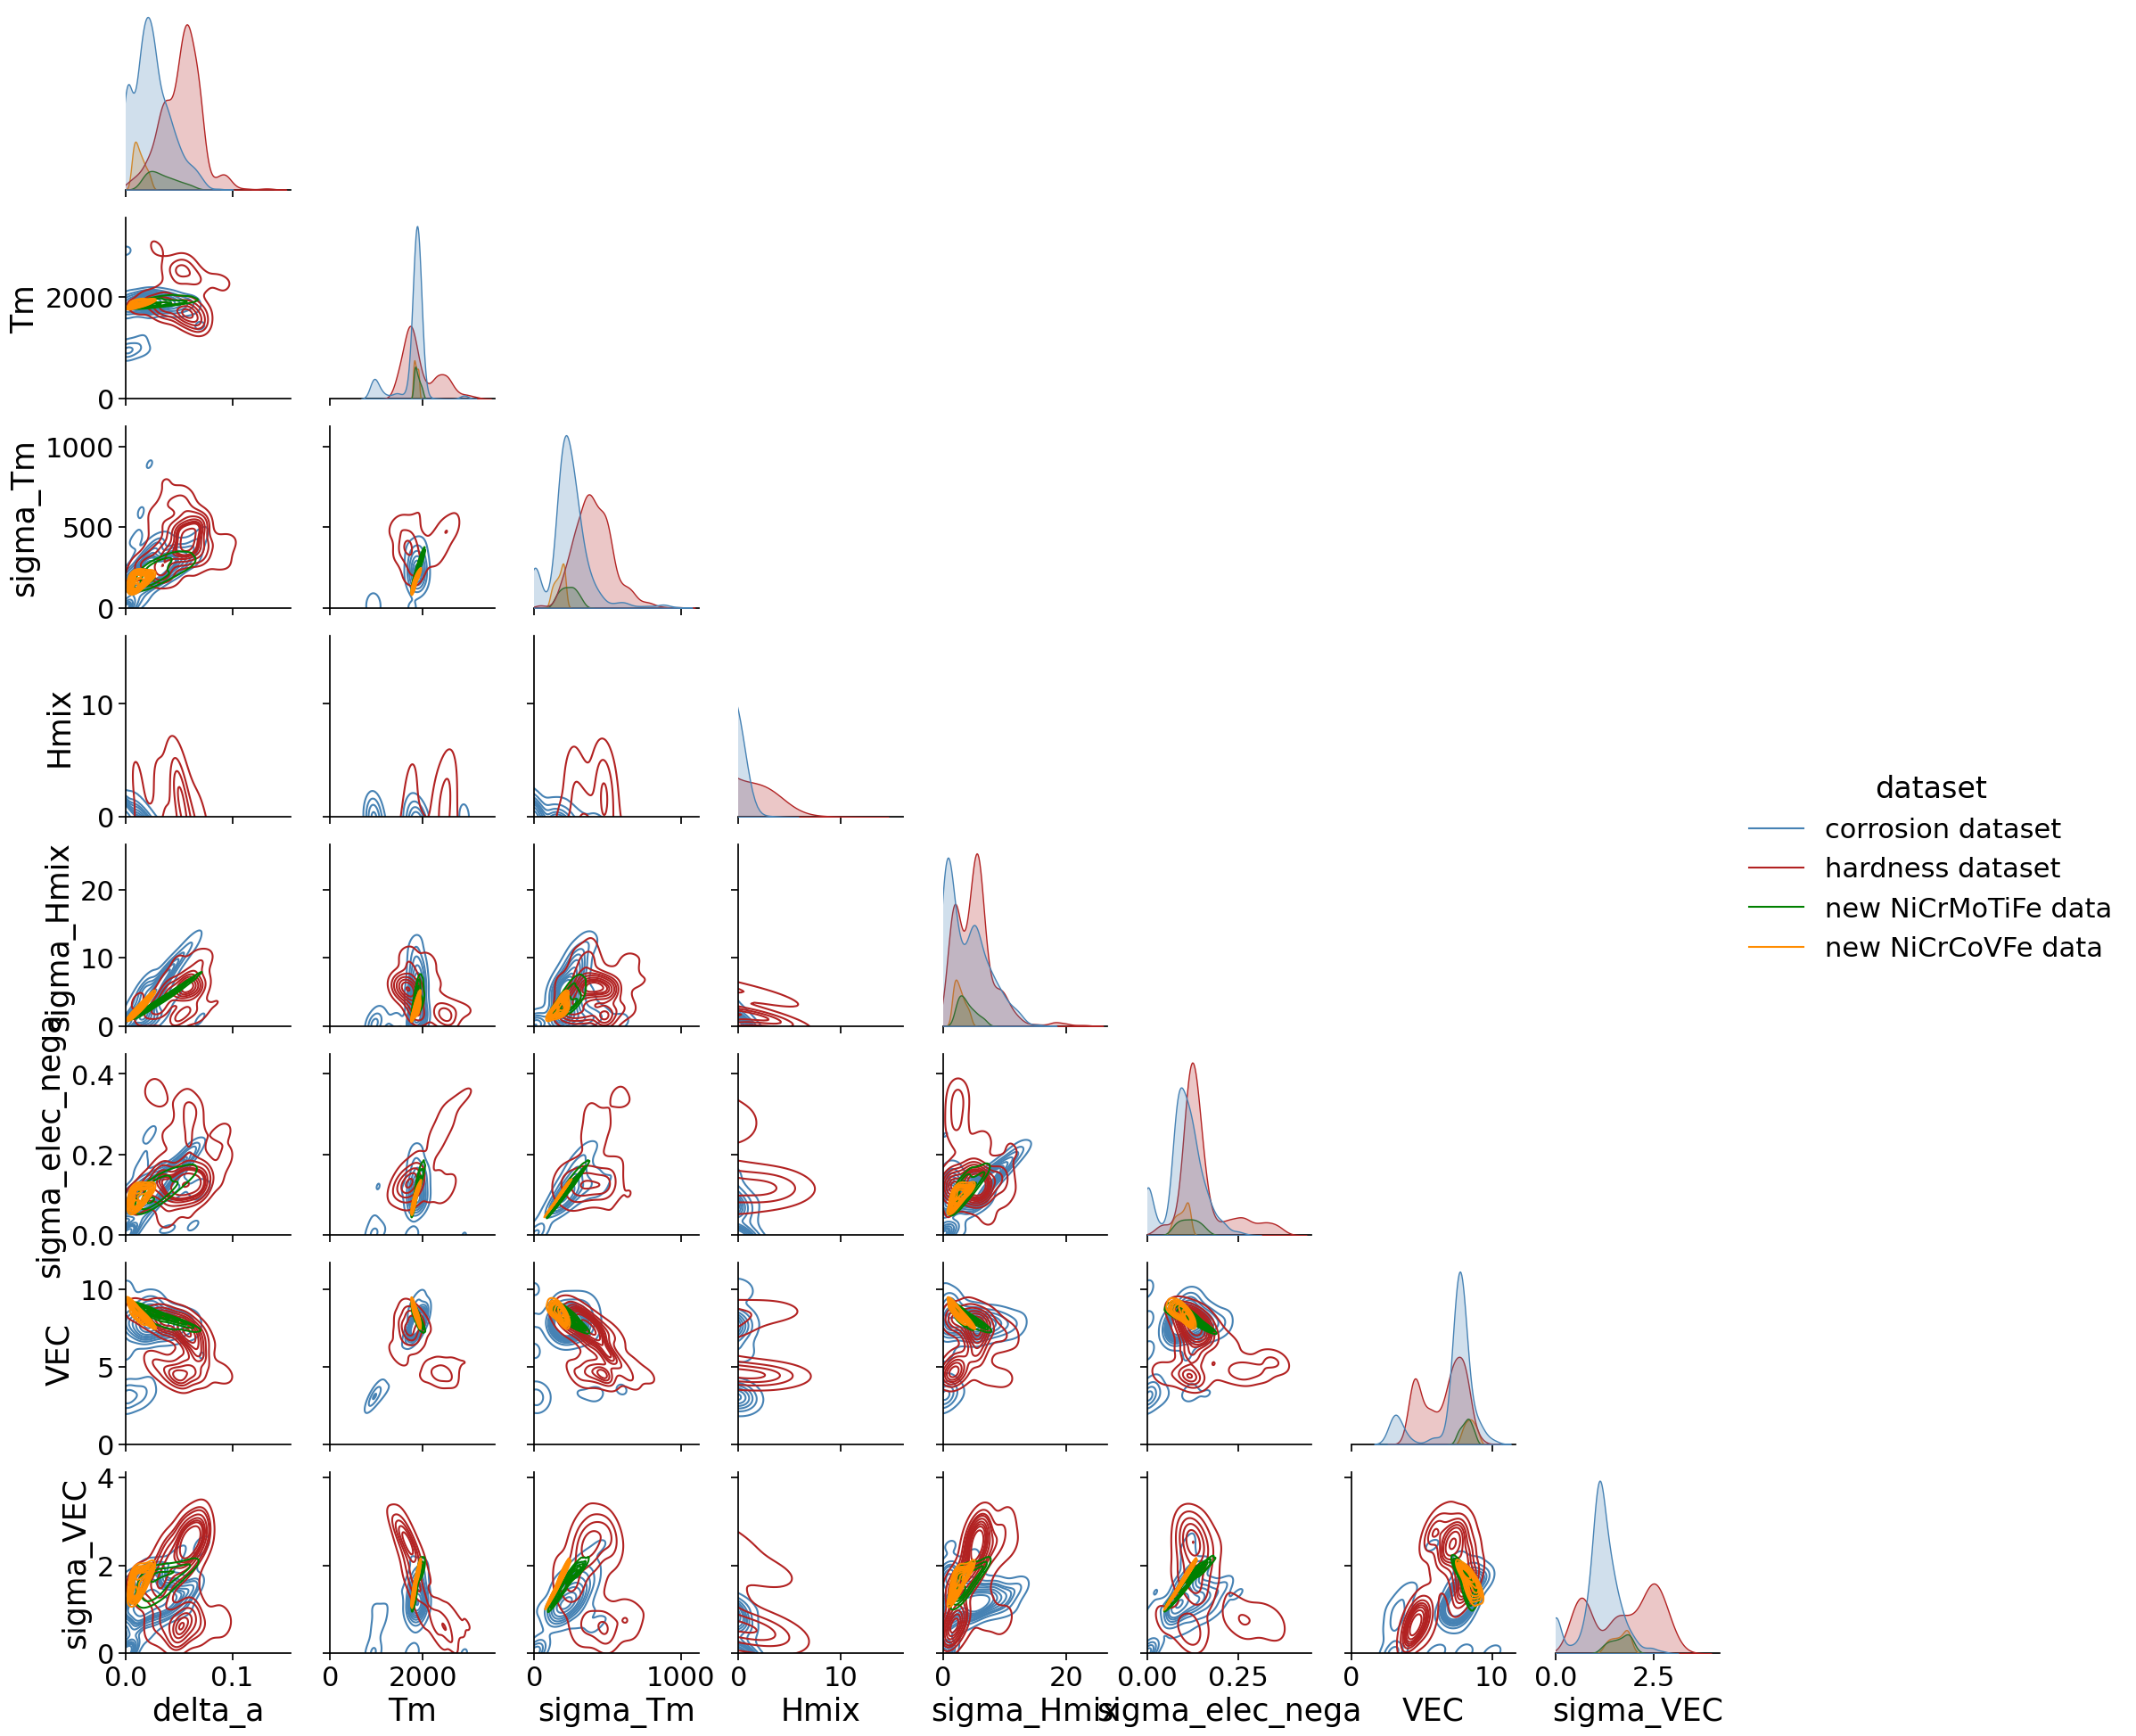

In [26]:
sns.set_context("notebook", font_scale=2)

# Define color palette for the pairplot
palette = ["steelblue", "firebrick", "green", "darkorange"]

# Create pairplot with KDE for all data
grid_kde = sns.pairplot(df_compo_specific_features_conc_new, vars=specific_features_sel_column,
                        hue="dataset", kind="kde", corner=True, palette=palette)

# Adjust x and y limits using list comprehension
_ = [[ax.set_xlim(left=0),
      ax.set_ylim(bottom=0),
      ax.xaxis.label.set_size(25),
      ax.yaxis.label.set_size(25)] for ax_row in grid_kde.axes for ax in ax_row if ax is not None]

plt.savefig('pairplot_feature_literature+new.pdf', bbox_inches='tight')
plt.show()

## 1. Let's try PCA (Principal Component Analysis)


In [27]:
def perform_pca(df, dim_name1='Principal Component 1', dim_name2='Principal Component 2'):
    df_pca = df.copy()

    # Scale the data
    # X_conc = StandardScaler().fit_transform(df_pca.drop(columns='dataset').values)
    X_conc = MinMaxScaler().fit_transform(df_pca.drop(columns='dataset').values)
    y_conc = df_pca['dataset'].values

    # Perform PCA
    pca = PCA()
    X_conc_r = pca.fit_transform(X_conc)
    X_conc_r = X_conc_r[:, :2]

    # Add the PCA components to the dataframe
    df_pca[dim_name1] = X_conc_r[:, 0]
    df_pca[dim_name2] = X_conc_r[:, 1]

    # Print explained variance ratio
    print(
        f"Explained variance ratio (first two components): {pca.explained_variance_ratio_[0:2]}")

    return df_pca


def plot_data(df_pca, title='PCA',
              dim_name1='Principal Component 1', dim_name2='Principal Component 2',
              x_label='Reduced Dimension 1 (UMAP)', y_label='Reduced Dimension 2 (UMAP)',
              axis_lim=[-1.3, 1.3, -1.3, 1.3], threshold=0.1, levels=5):

    # Set up the plot
    colors = ["steelblue", "firebrick", "green", "darkorange"]
    # colors = ["steelblue", "firebrick"]
    
    # Create a joint plot with KDE contour
    g = sns.jointplot(data=df_pca, x=dim_name1, y=dim_name2,
                      hue='dataset', palette=colors, alpha=0.4)
    g.plot_joint(sns.kdeplot, zorder=0, palette=colors,
                 levels=levels, linewidths=1, alpha=0.75, thresh=threshold)

    # Customize the plot
    g.ax_joint.grid(linewidth=0.1, alpha=.25)
    g.ax_joint.set_xlabel(x_label, fontsize=20)
    g.ax_joint.set_ylabel(y_label, fontsize=20)
    g.ax_joint.tick_params(labelsize=20)
    # g.ax_joint.set_aspect('equal', 'box')
    g.ax_joint.set_xlim(axis_lim[0], axis_lim[1])
    g.ax_joint.set_ylim(axis_lim[2], axis_lim[3])
    # g.ax_joint.set_title(title, fontsize=20, y=1.5)
    # g.ax_joint.legend(loc='upper right', fontsize=22, bbox_to_anchor=(2.5, 1))
    g.ax_joint.legend(loc='upper right', fontsize=22,
                      bbox_to_anchor=(2.5, 1), labelspacing=0.05)

    # Set the same limits for the marginal plots
    g.ax_marg_x.set_xlim(axis_lim[0], axis_lim[1])
    g.ax_marg_y.set_ylim(axis_lim[2], axis_lim[3])

    plt.savefig(title + '.pdf', bbox_inches='tight')
    plt.show()

Explained variance ratio (first two components): [0.24339372 0.18287113]
Explained variance ratio (first two components): [0.23460085 0.19482752]


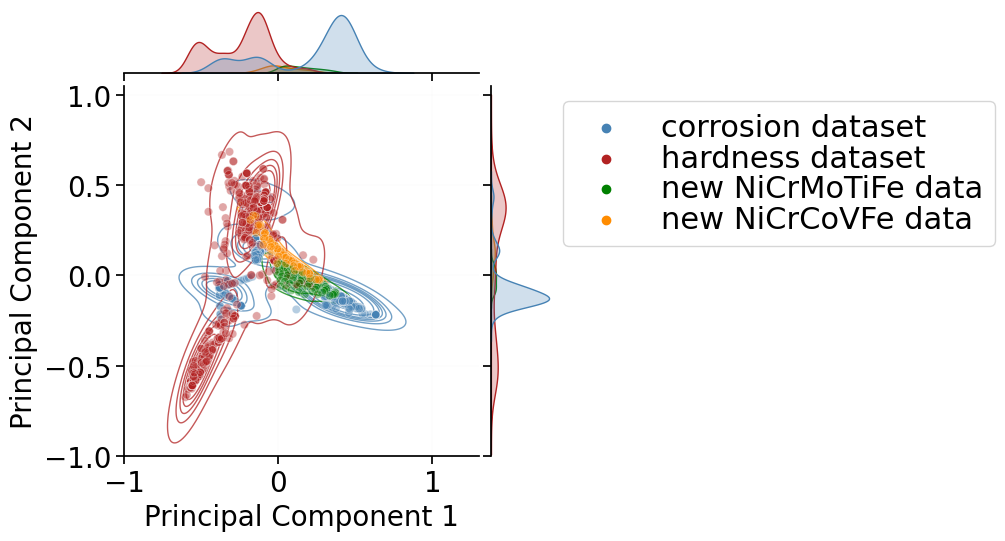

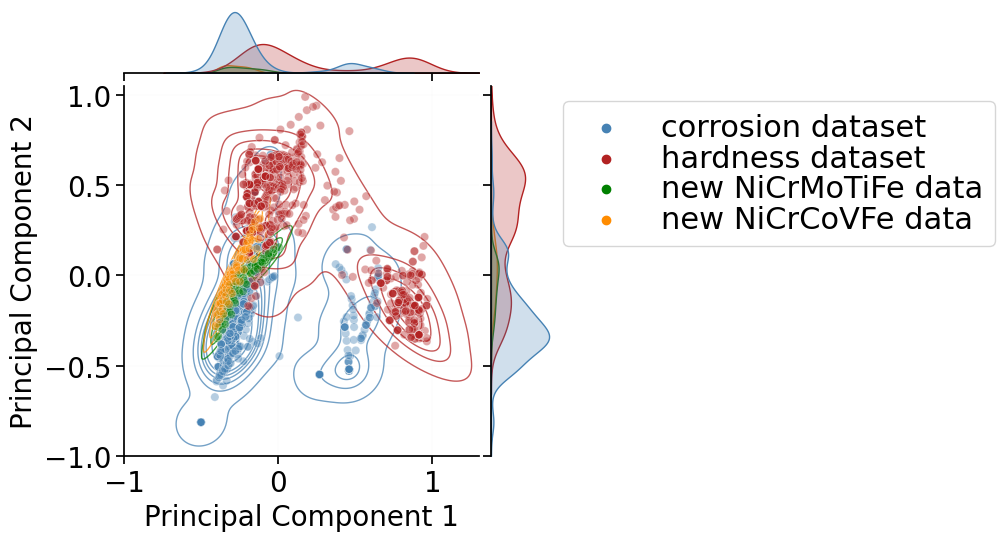

In [28]:
# Perform PCA on df_compo_conc_new
df_compo_conc_new_pca = perform_pca(
    df_compo_conc_new, dim_name1='Principal Component 1', dim_name2='Principal Component 2')

# Perform PCA on df_compo_specific_features_conc_new
df_compo_specific_features_conc_new_pca = perform_pca(df_compo_specific_features_conc_new,
                                                      dim_name1='Principal Component 1',
                                                      dim_name2='Principal Component 2')

# Plot data for df_compo_conc_new_pca
plot_data(df_compo_conc_new_pca, title='PCA 2D_Compositional Space',
          dim_name1='Principal Component 1', dim_name2='Principal Component 2',
          x_label='Principal Component 1', y_label='Principal Component 2',
          axis_lim=[-1, 1.3, -1, 1.05],
          #   axis_lim=[-5, 10, -5, 5],
          threshold=0.02, levels=8)

# Plot data for df_compo_specific_features_conc_new_pca
plot_data(df_compo_specific_features_conc_new_pca, title='PCA 2D_Compositional and Engineered Feature Space',
          dim_name1='Principal Component 1', dim_name2='Principal Component 2',
          x_label='Principal Component 1', y_label='Principal Component 2',
          axis_lim=[-1, 1.3, -1, 1.05],
          #   axis_lim=[-5, 10, -5, 5],
          threshold=0.02, levels=8)

## 2. Let's try UMAP (Uniform Manifold Approximation and Projection)


In [29]:

def perform_umap(df, n_neighbors=30, min_dist=0.6, n_components=2, metric='mahalanobis',
                 dim_name1='UMAP Component 1', dim_name2='UMAP Component 2', random_state=42):
    df_umap = df.copy()

    np.random.seed(random_state)
    random.seed(random_state)
    set_num_threads(1)

    # # scaler = StandardScaler()
    # scaler = MinMaxScaler()
    # X = df_umap.drop(columns='dataset').values

    # # Scale the data
    # X_conc = scaler.fit_transform(X)
    # y_conc = df_umap['dataset'].values

    # Scale the data
    X_conc = MinMaxScaler().fit_transform(df_umap.drop(columns='dataset').values)
    y_conc = df_umap['dataset'].values


    # Calculate inverse covariance matrix if using 'mahalanobis' metric
    if metric == 'mahalanobis':
        cov = EmpiricalCovariance().fit(X_conc)
        inv_cov_matrix = inv(cov.covariance_)
        metric_kwds = {'VI': inv_cov_matrix}
    else:
        metric_kwds = {}
   
    # Perform UMAP
    reducer = umap.UMAP(n_neighbors=n_neighbors,
                        min_dist=min_dist,
                        n_components=n_components,
                        metric=metric,
                        metric_kwds=metric_kwds,
                        random_state=random_state)
    
    X_conc_r = reducer.fit_transform(X_conc)

    # Add the UMAP components to the dataframe
    df_umap[dim_name1] = X_conc_r[:, 0]
    df_umap[dim_name2] = X_conc_r[:, 1]

    return df_umap

In [30]:
# # Perform UMAP on df_compo_conc_new (composition only)
# df_compo_conc_new_umap = perform_umap(df_compo_conc_new,
#                                       n_neighbors=20, min_dist=0.5, n_components=2, metric='mahalanobis',
#                                       dim_name1='UMAP Component 1', dim_name2='UMAP Component 2',
#                                       random_state=42)

# plot_data(df_compo_conc_new_umap, title='UMAP 2D_Compositional Space',
#           dim_name1='UMAP Component 1', dim_name2='UMAP Component 2',
#           axis_lim=[-100, 100, -50, 50], threshold=0.001, levels=30)

,Fe,Cr,Ni,Mo,W,N,Nb,C,Si,Mn,...,Tm,sigma_Tm,Hmix,sigma_Hmix,sigma_elec_nega,VEC,sigma_VEC,dataset,UMAP Component 1,UMAP Component 2
0,69.77,18.0,10.0,0.0,0.0,0.0,0.0,0.03,1.0,1.0,...,1869.874935,173.330067,-4.484751,4.974488,0.083927,7.719083,1.188494,corrosion dataset,10.596608,-1.496571


/home/yuxiangw/miniconda3/envs/tf/lib/python3.9/site-packages/seaborn/axisgrid.py:1826: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  func(x=self.x, y=self.y, **kwargs)
/home/yuxiangw/miniconda3/envs/tf/lib/python3.9/site-packages/seaborn/axisgrid.py:1877: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  func(x=self.x, ax=self.ax_marg_x, **kwargs)
/home/yuxiangw/miniconda3/envs/tf/lib/python3.9/site-packages/seaborn/axisgrid.py:1883: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  func(y=self.y, ax=self.ax_marg_y, **kwargs)
/home/yuxiangw/miniconda3/envs/tf/lib/python3.9/site-packages/seaborn/axisgrid.py:1826: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  func(x=self.x, y=self.y, **kwargs)


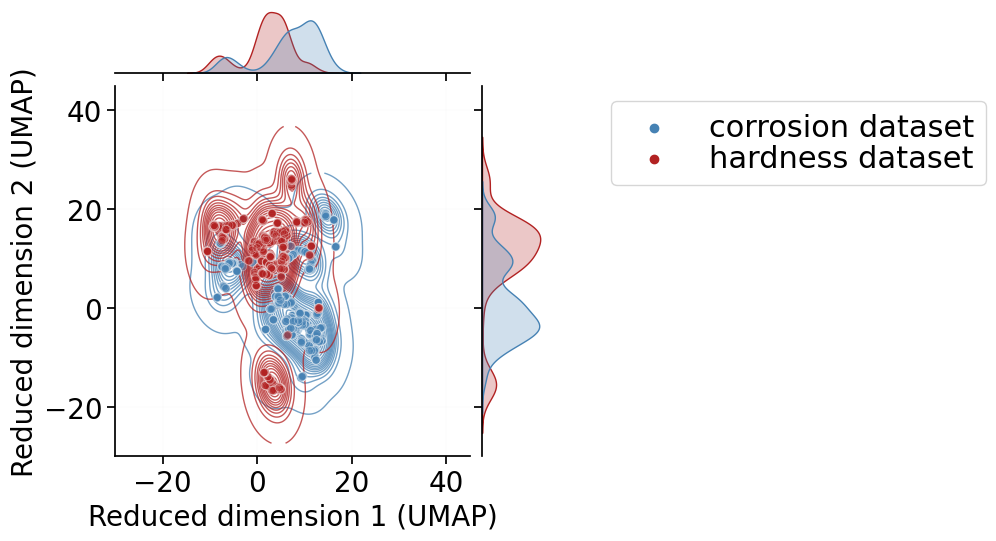

In [31]:
np.random.seed(42)

# display(df_compo_specific_features_conc_new.head(1))

# Perform UMAP on df_compo_specific_features_conc_new
df_compo_specific_features_conc_new_umap = perform_umap(df_compo_specific_features_conc_new,
                                                        n_neighbors=20, min_dist=0.5, n_components=2, metric='mahalanobis',
                                                        dim_name1='UMAP Component 1', dim_name2='UMAP Component 2',
                                                        random_state=42)

df_HC_umap = df_compo_specific_features_conc_new_umap[
    (df_compo_specific_features_conc_new_umap['dataset'] == 'corrosion dataset') |
    (df_compo_specific_features_conc_new_umap['dataset'] == 'hardness dataset')]

display(df_HC_umap.head(1))

# Plot data for df_compo_specific_features_conc_new_umap
plot_data(df_HC_umap, title='UMAP_2D_Compositional and Engineered Feature Space',
          dim_name1='UMAP Component 1', dim_name2='UMAP Component 2',
          x_label='Reduced dimension 1 (UMAP)', y_label='Reduced dimension 2 (UMAP)',
          axis_lim=[-30, 45, -30, 45], threshold=0.001, levels=20)

## 3. Let's try to use literature-reference Mahalanobis analysis

### Multivariate analysis relative to corrosion and hardness literature reference sets


Here we use the composition space for the Mahalanobis analysis.


In [32]:
df_C_umap = df_compo_specific_features_conc_new_umap[
    df_compo_specific_features_conc_new_umap['dataset'] == 'corrosion dataset']
df_H_umap = df_compo_specific_features_conc_new_umap[
    df_compo_specific_features_conc_new_umap['dataset'] == 'hardness dataset']
df_new_FeCrNiMoTi_umap = df_compo_specific_features_conc_new_umap[
    df_compo_specific_features_conc_new_umap['dataset'] == 'new NiCrMoTiFe data']
df_new_FeCrNiCoV_umap = df_compo_specific_features_conc_new_umap[
    df_compo_specific_features_conc_new_umap['dataset'] == 'new NiCrCoVFe data']


# prepare the df for calculating Mahalanobis distance (cannot have string in df)
# display(df_C_umap.iloc[[0, -1]], df_C_umap.shape,
#         df_H_umap.iloc[[0, -1]], df_H_umap.shape,
#         df_new_FeCrNiMoTi_umap.iloc[[0, -1]], df_new_FeCrNiMoTi_umap.shape,
#         df_new_FeCrNiCoV_umap.iloc[[0, -1]], df_new_FeCrNiCoV_umap.shape)

Preparing the literature reference sets and score tables


In [33]:
# Score tables: literature + both new datasets
df_C_score = pd.concat(
    [df_C_umap, df_new_FeCrNiMoTi_umap, df_new_FeCrNiCoV_umap],
    ignore_index=True
)

df_H_score = pd.concat(
    [df_H_umap, df_new_FeCrNiMoTi_umap, df_new_FeCrNiCoV_umap],
    ignore_index=True
)


def prepare_reference_and_score(df_ref, df_score):
    ref_num = df_ref[compo_column].fillna(0).copy()
    score_num = df_score[compo_column].fillna(0).copy()
    score_label = df_score[['dataset', 'UMAP Component 1', 'UMAP Component 2']].copy()

    return ref_num, score_num, score_label


df_C_ref_num, df_C_score_num, df_C_score_label = prepare_reference_and_score(
    df_C_umap, df_C_score
)
df_H_ref_num, df_H_score_num, df_H_score_label = prepare_reference_and_score(
    df_H_umap, df_H_score
)


Calculate the squared Mahalanobis distance relative to the literature reference sets


In [34]:
def calculate_mahalanobis_sq(y=None, data=None, cov=None):
    # Squared Mahalanobis distance of each row in y relative to reference data
    mu = data.mean(axis=0)
    y_mu = y - mu

    if cov is None:
        cov = np.cov(data.values.T)
        cov += np.eye(cov.shape[0]) * 1e-6

    inv_covmat = np.linalg.pinv(cov)
    left = np.dot(y_mu, inv_covmat)
    mahal_sq = np.dot(left, y_mu.T)

    return mahal_sq.diagonal()


def empirical_tail_probability(score_values, reference_values):
    ref = np.asarray(reference_values)
    score = np.asarray(score_values)

    # Empirical survival probability; never exactly zero
    return ((ref[:, None] >= score[None, :]).sum(axis=0) + 1) / (len(ref) + 1)


# Reference distances: literature scored against literature reference
md2_C_ref = calculate_mahalanobis_sq(y=df_C_ref_num, data=df_C_ref_num)
md2_H_ref = calculate_mahalanobis_sq(y=df_H_ref_num, data=df_H_ref_num)

# Score all points (literature + both new datasets) against literature-only reference
md2_C_score = calculate_mahalanobis_sq(y=df_C_score_num, data=df_C_ref_num)
md2_H_score = calculate_mahalanobis_sq(y=df_H_score_num, data=df_H_ref_num)

# Store results
df_C_score_Mahl = df_C_score_num.copy()
df_H_score_Mahl = df_H_score_num.copy()

df_C_score_Mahl['Mahalanobis_sq'] = md2_C_score
df_H_score_Mahl['Mahalanobis_sq'] = md2_H_score

df_C_score_Mahl['empirical_tail_prob'] = empirical_tail_probability(md2_C_score, md2_C_ref)
df_H_score_Mahl['empirical_tail_prob'] = empirical_tail_probability(md2_H_score, md2_H_ref)

# Reattach labels
df_C_score_Mahl_label = pd.concat([df_C_score_Mahl, df_C_score_label], axis=1)
df_H_score_Mahl_label = pd.concat([df_H_score_Mahl, df_H_score_label], axis=1)

display(df_C_score_Mahl_label.iloc[[0, -1]])


,Fe,Cr,Ni,Mo,W,N,Nb,C,Si,Mn,...,Co,Mg,Y,Zr,Hf,Mahalanobis_sq,empirical_tail_prob,dataset,UMAP Component 1,UMAP Component 2
0,69.770000,18.000000,10.000000,0.0,0.0,0.0,0.0,0.03,1.0,1.0,...,0.00000,0.0,0.0,0.0,0.0,2.317820,0.845722,corrosion dataset,10.596608,-1.496571
849,51.347188,5.827793,31.584854,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,3.09787,0.0,0.0,0.0,0.0,176.055886,0.019635,new NiCrCoVFe data,-1.983619,7.062006


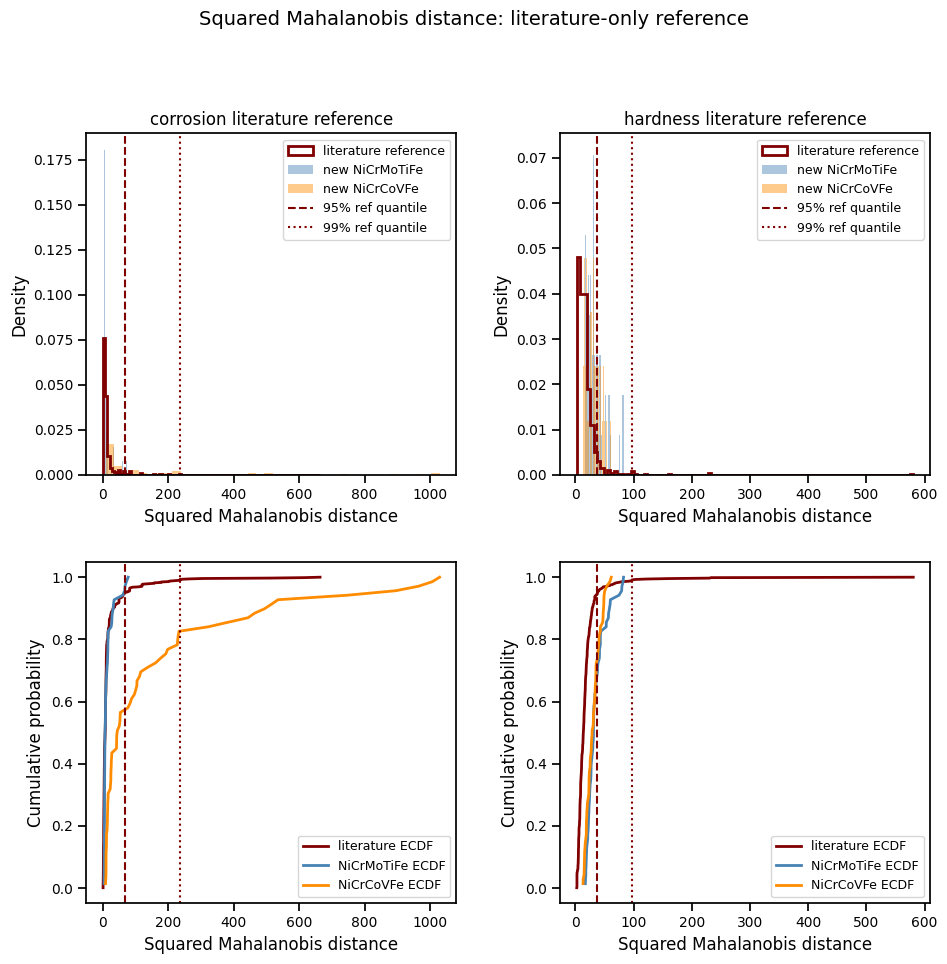

In [35]:
dfs = [df_C_score_Mahl_label, df_H_score_Mahl_label]
ref_md2s = [md2_C_ref, md2_H_ref]
dataset_specs = [
    ('corrosion literature reference', 'corrosion dataset'),
    ('hardness literature reference', 'hardness dataset')
]

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Squared Mahalanobis distance: literature-only reference', fontsize=14)

for i, (df, ref_md2, (title, ref_label)) in enumerate(zip(dfs, ref_md2s, dataset_specs)):
    df_ref_plot = df[df['dataset'] == ref_label]
    df_moti_plot = df[df['dataset'] == 'new NiCrMoTiFe data']
    df_cov_plot = df[df['dataset'] == 'new NiCrCoVFe data']

    # Top row: density histograms
    axs[0, i].hist(ref_md2, bins=100,
                   histtype='step', linewidth=2, density=True,
                   color='maroon', label='literature reference')
    axs[0, i].hist(df_moti_plot['Mahalanobis_sq'], bins=40,
                   alpha=0.45, density=True, color='steelblue',
                   label='new NiCrMoTiFe')
    axs[0, i].hist(df_cov_plot['Mahalanobis_sq'], bins=40,
                   alpha=0.45, density=True, color='darkorange',
                   label='new NiCrCoVFe')
    axs[0, i].axvline(np.quantile(ref_md2, 0.95), color='maroon', linestyle='--', linewidth=1.5,
                      label='95% ref quantile')
    axs[0, i].axvline(np.quantile(ref_md2, 0.99), color='maroon', linestyle=':', linewidth=1.5,
                      label='99% ref quantile')
    axs[0, i].set_xlabel('Squared Mahalanobis distance', fontsize=12)
    axs[0, i].set_ylabel('Density', fontsize=12)
    axs[0, i].set_title(title, fontsize=12)
    axs[0, i].tick_params(axis='both', labelsize=10)
    axs[0, i].legend(fontsize=9)

    # Bottom row: cumulative comparison
    x_ref = np.sort(ref_md2)
    y_ref = np.arange(1, len(x_ref) + 1) / len(x_ref)
    axs[1, i].plot(x_ref, y_ref, color='maroon', lw=2, label='literature ECDF')
    x_moti = np.sort(df_moti_plot['Mahalanobis_sq'].to_numpy())
    y_moti = np.arange(1, len(x_moti) + 1) / len(x_moti)
    axs[1, i].plot(x_moti, y_moti, color='steelblue', lw=2, label='NiCrMoTiFe ECDF')
    x_cov = np.sort(df_cov_plot['Mahalanobis_sq'].to_numpy())
    y_cov = np.arange(1, len(x_cov) + 1) / len(x_cov)
    axs[1, i].plot(x_cov, y_cov, color='darkorange', lw=2, label='NiCrCoVFe ECDF')
    axs[1, i].axvline(np.quantile(ref_md2, 0.95), color='maroon', linestyle='--', linewidth=1.5)
    axs[1, i].axvline(np.quantile(ref_md2, 0.99), color='maroon', linestyle=':', linewidth=1.5)
    axs[1, i].set_xlabel('Squared Mahalanobis distance', fontsize=12)
    axs[1, i].set_ylabel('Cumulative probability', fontsize=12)
    axs[1, i].tick_params(axis='both', labelsize=10)
    axs[1, i].legend(fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Use the empirical distribution of literature-reference distances to convert squared Mahalanobis distance into empirical tail probabilities.

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4381501/


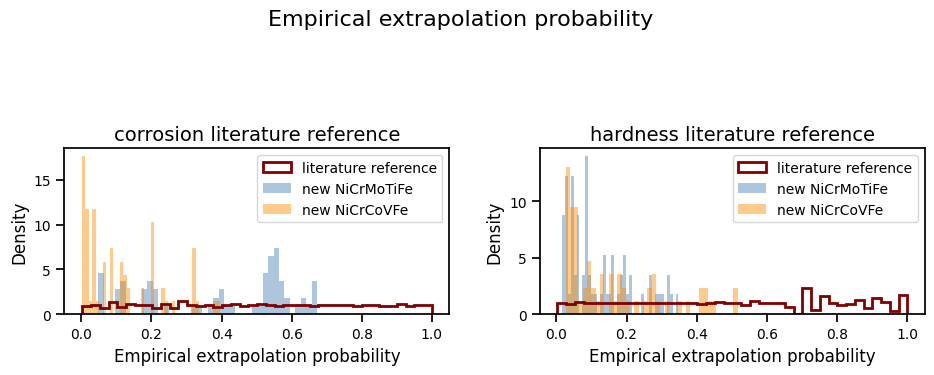

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Empirical extrapolation probability', fontsize=16)

for i, (df, (title, ref_label)) in enumerate(zip(dfs, dataset_specs)):
    df_ref_plot = df[df['dataset'] == ref_label]
    df_moti_plot = df[df['dataset'] == 'new NiCrMoTiFe data']
    df_cov_plot = df[df['dataset'] == 'new NiCrCoVFe data']

    axs[i].hist(df_ref_plot['empirical_tail_prob'], bins=40,
                histtype='step', linewidth=2, density=True,
                color='maroon', label='literature reference')
    axs[i].hist(df_moti_plot['empirical_tail_prob'], bins=40,
                alpha=0.45, density=True, color='steelblue',
                label='new NiCrMoTiFe')
    axs[i].hist(df_cov_plot['empirical_tail_prob'], bins=40,
                alpha=0.45, density=True, color='darkorange',
                label='new NiCrCoVFe')

    axs[i].set_xlabel('Empirical extrapolation probability', fontsize=12)
    axs[i].set_ylabel('Density', fontsize=12)
    axs[i].set_title(title, fontsize=14)
    axs[i].tick_params(axis='both', labelsize=10)
    axs[i].legend(fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

We use the empirical extrapolation probability as a novelty score, where smaller values indicate more extreme points relative to the literature reference set. Next, we map this score back to the 2D UMAP projection and to the PVD wafer representation.


Map the empirical tail probabilities back to the UMAP 2D projection: the variation is not monotonic on this projection.

The new dataset family is highlighted, while the literature points remain translucent in the background.


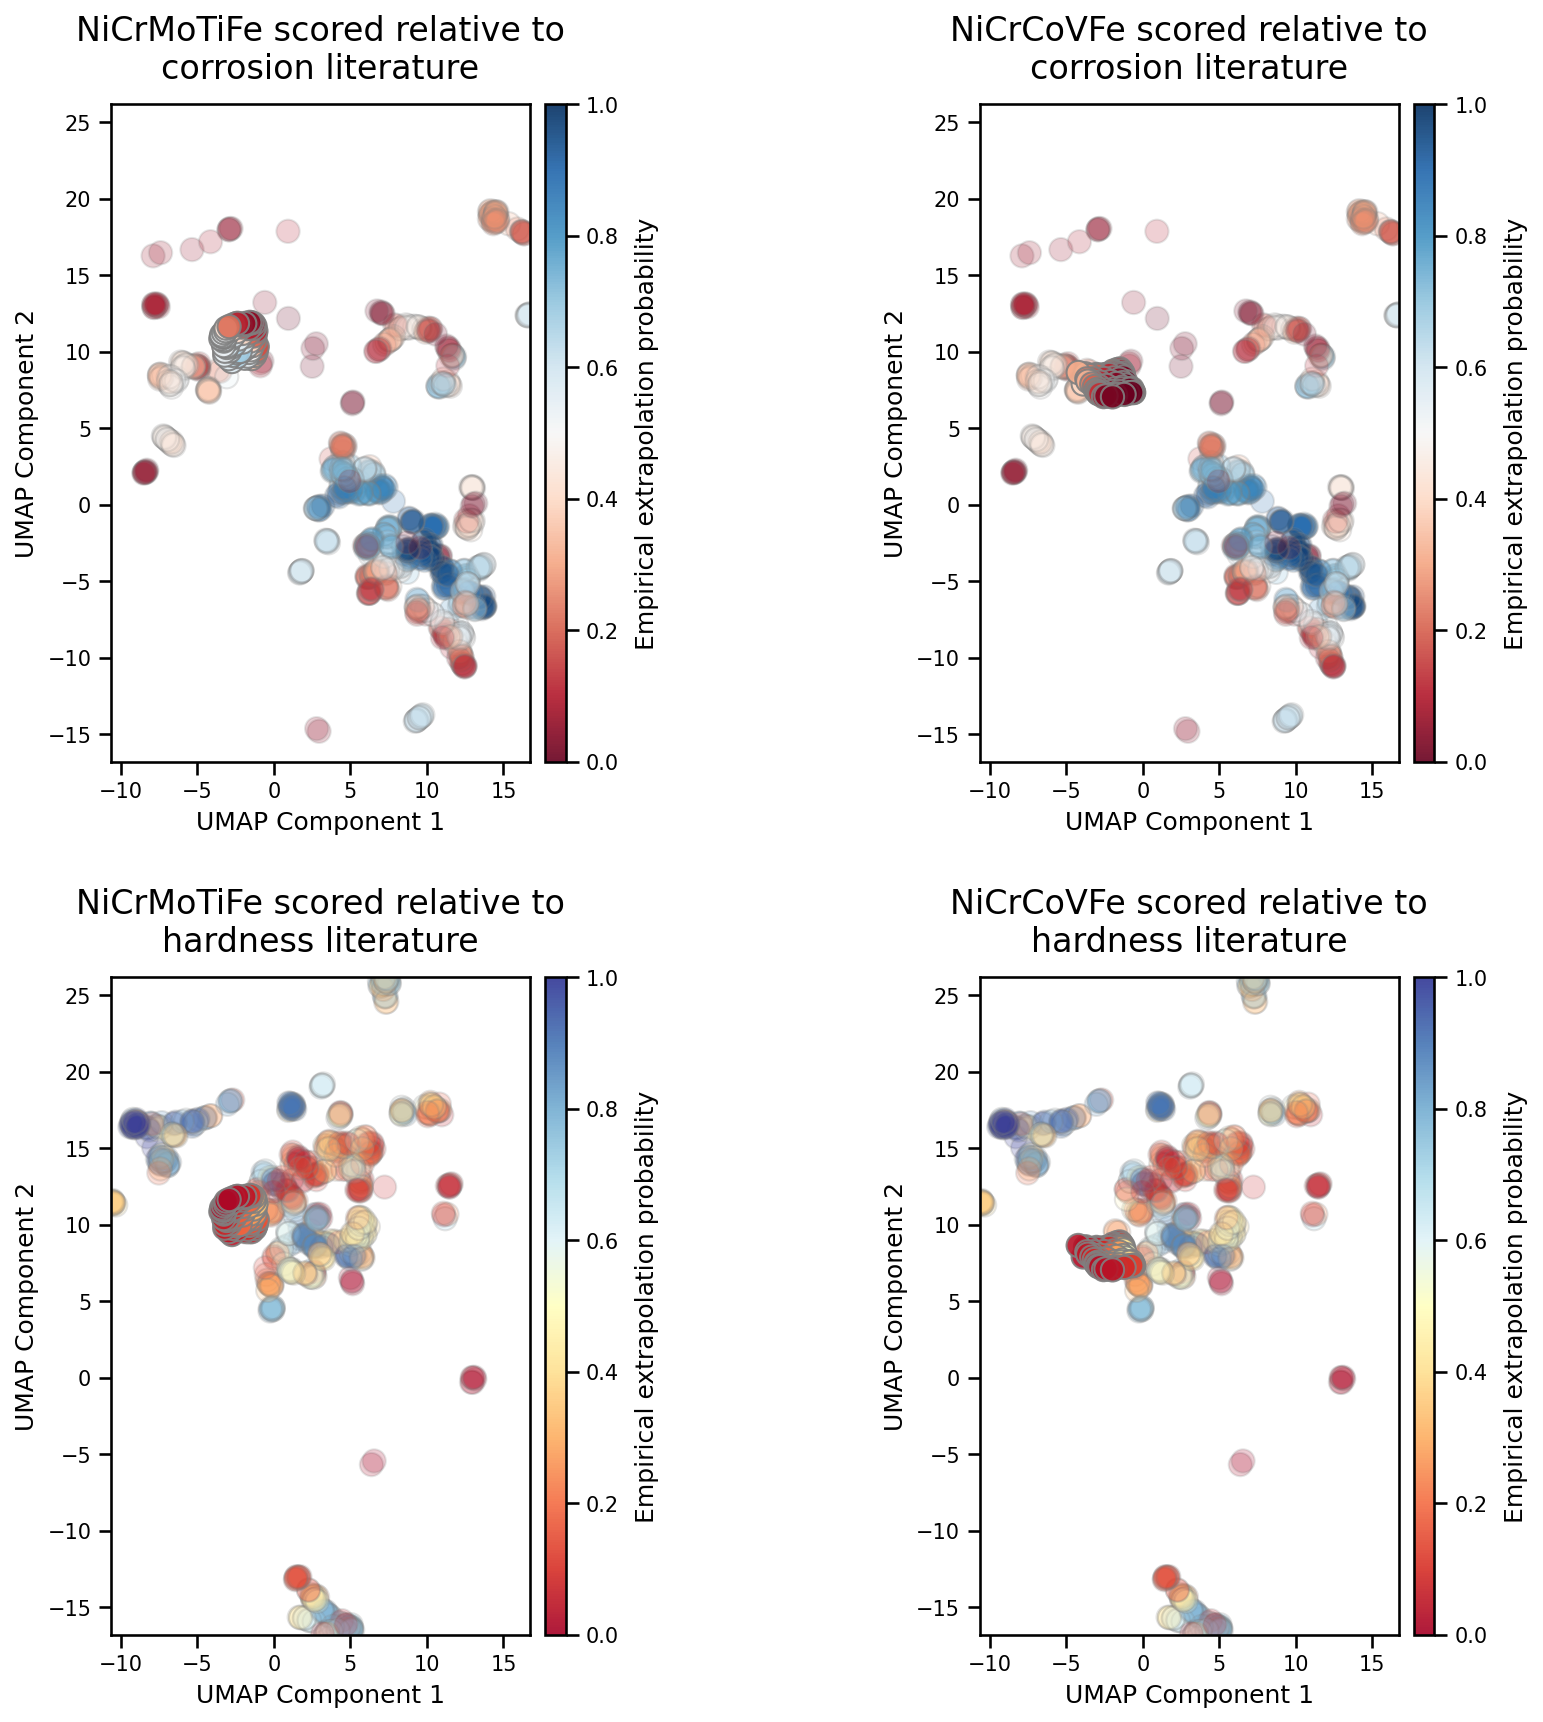

In [37]:
def create_scatter(df, dataset_values, ax, cmap="RdBu", titlename="name?"):
    df_literature = df[df["dataset"] == dataset_values[0]]
    df_new = df[df["dataset"] == dataset_values[1]]

    scatters = []
    for dfi, alpha in zip([df_literature, df_new], [0.2, 0.9]):
        scatter = ax.scatter(
            dfi["UMAP Component 1"], dfi["UMAP Component 2"],
            c=dfi["empirical_tail_prob"], cmap=cmap,
            edgecolor="grey", s=500, marker='.', alpha=alpha, vmin=0, vmax=1
        )
        scatters.append(scatter)

    ax.set_xlabel("UMAP Component 1", fontsize=12)
    ax.set_ylabel("UMAP Component 2", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_title(titlename, fontsize=16, y=1.02)
    ax.set_aspect('equal', 'box')

    return scatters


fig, ax = plt.subplots(2, 2, figsize=(12, 12), dpi=150)

datasets = [
    (df_C_score_Mahl_label, ['corrosion dataset', 'new NiCrMoTiFe data'], "RdBu",
     'NiCrMoTiFe scored relative to\ncorrosion literature', 'NiCrMoTiFe_corrosion_literature_ref'),
    (df_C_score_Mahl_label, ['corrosion dataset', 'new NiCrCoVFe data'], "RdBu",
     'NiCrCoVFe scored relative to\ncorrosion literature', 'NiCrCoVFe_corrosion_literature_ref'),
    (df_H_score_Mahl_label, ['hardness dataset', 'new NiCrMoTiFe data'], "RdYlBu",
     'NiCrMoTiFe scored relative to\nhardness literature', 'NiCrMoTiFe_hardness_literature_ref'),
    (df_H_score_Mahl_label, ['hardness dataset', 'new NiCrCoVFe data'], "RdYlBu",
     'NiCrCoVFe scored relative to\nhardness literature', 'NiCrCoVFe_hardness_literature_ref')
]

xmin, xmax = min(df['UMAP Component 1'].min() for df, _, _, _, _ in datasets), max(
    df['UMAP Component 1'].max() for df, _, _, _, _ in datasets)
ymin, ymax = min(df['UMAP Component 2'].min() for df, _, _, _, _ in datasets), max(
    df['UMAP Component 2'].max() for df, _, _, _, _ in datasets)

for i, (df, dataset_values, cmap, title, output_stub) in enumerate(datasets):
    axi = ax[i//2, i % 2]
    scatters = create_scatter(df, dataset_values, axi, cmap=cmap, titlename=title)

    axi.set_xlim(xmin, xmax)
    axi.set_ylim(ymin, ymax)

    divider = make_axes_locatable(axi)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = fig.colorbar(scatters[-1], cax=cax)
    cbar.set_label("Empirical extrapolation probability", size=12, labelpad=8)
    cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('UMAP_2D_Mahalanobis.png')
plt.show()

Now I will plot the empirical extrapolation probability on the PVD wafer representation.


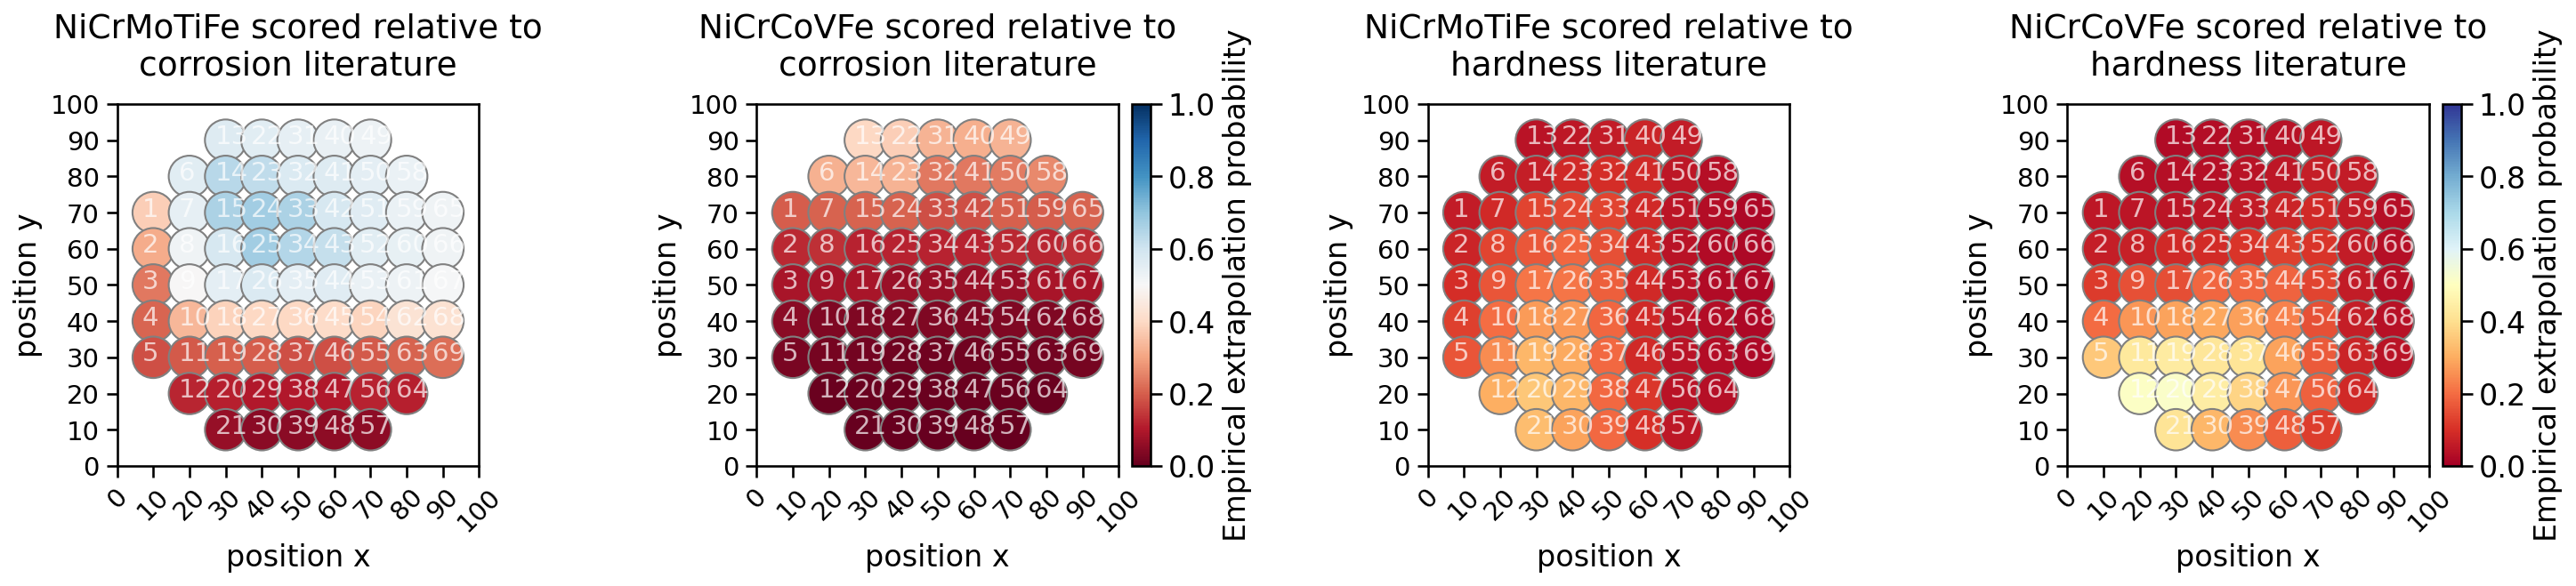

In [38]:
PVD_x_y = pd.read_excel(data_path + 'PVD_x_y.xlsx')


def create_PVD_scatter(df, PVD_x_y, dataset_values, ax, cmap="RdBu", title="", output_stub=""):
    df_new = df[df["dataset"] == dataset_values[1]].copy()

    if len(df_new) != len(PVD_x_y):
        raise ValueError(f"Row mismatch: {len(df_new)} scores vs {len(PVD_x_y)} PVD coordinates")

    scatter = ax.scatter(PVD_x_y["x"], PVD_x_y["y"], c=df_new["empirical_tail_prob"], cmap=cmap, edgecolor="grey",
                         s=2000, marker='.', alpha=1, vmin=0, vmax=1)

    for i, txt in enumerate(PVD_x_y.index+1):
        ax.annotate(txt, (PVD_x_y["x"].iloc[i]-3, PVD_x_y["y"].iloc[i]-1),
                    color="white", alpha=0.7, fontsize=14)

    ax.set_xlabel("position x", fontsize=16)
    ax.set_ylabel("position y", fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_title(title, fontsize=18, y=1.05)
    ax.set_aspect(1)
    ax.set_xticks(range(0, 101, 10))
    ax.set_xticklabels(ax.get_xticks(), rotation=45)
    ax.set_yticks(range(0, 101, 10))

    # if output_stub:
    #     df_new.to_csv(output_stub + '_empirical_tail_probability.csv', index=False)

    return scatter


fig, ax = plt.subplots(1, 4, figsize=(20, 4.7), dpi=150)

for i, (df, dataset_values, cmap, title, output_stub) in enumerate(datasets):
    axi = ax[i]
    scatter = create_PVD_scatter(
        df, PVD_x_y, dataset_values, axi, cmap=cmap, title=title, output_stub=output_stub)

    # Only add colorbar to the last subplot
    if i == len(datasets) - 1 or i == len(datasets)/2 - 1:
        divider = make_axes_locatable(axi)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = fig.colorbar(scatter, cax=cax)
        cbar.set_label('Empirical extrapolation probability',
                       size=16)
        cbar.ax.tick_params(labelsize=16)

plt.tight_layout()
plt.savefig('PVD_2D_Mahalanobis.pdf', bbox_inches='tight')
plt.show()

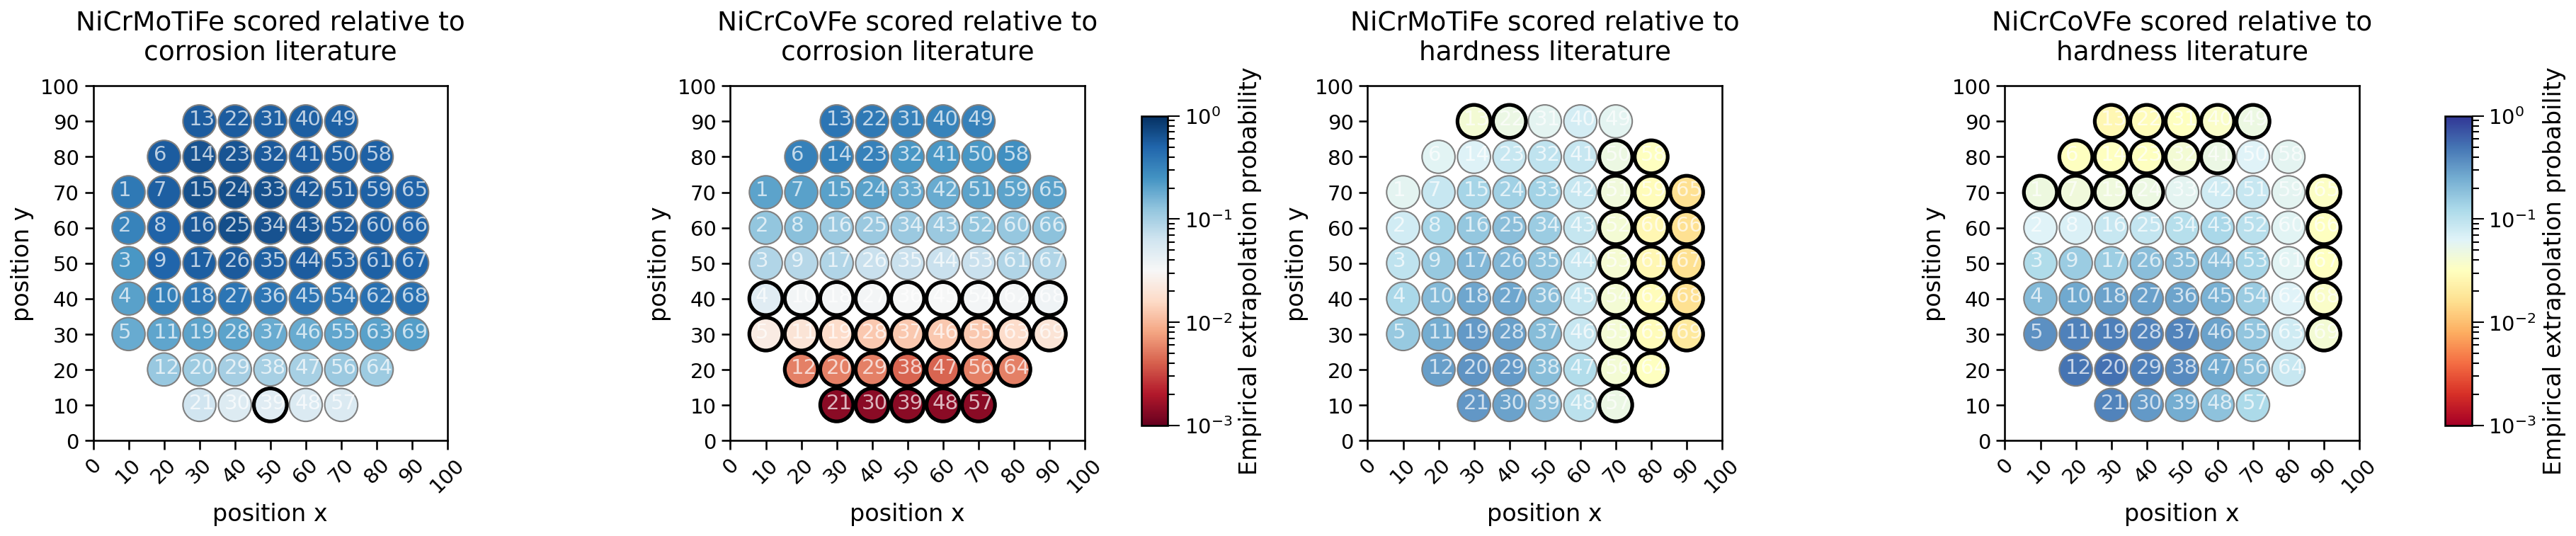

In [39]:
PVD_x_y = pd.read_excel(os.path.join(data_path, 'PVD_x_y.xlsx'))


def make_safe_filename(text):
    text = str(text).replace("\n", " ")
    text = re.sub(r'[\\/*?:"<>|]', "", text)
    text = re.sub(r"\s+", "_", text.strip())
    return text


def create_PVD_scatter_log(
    df,
    PVD_x_y,
    dataset_values,
    ax,
    cmap="RdBu",
    title="",
    export_name=None,
    norm=None
):
    df_new = df[df["dataset"] == dataset_values[1]].copy()

    if len(df_new) != len(PVD_x_y):
        raise ValueError(
            f"Row mismatch: {len(df_new)} scores vs {len(PVD_x_y)} PVD coordinates"
        )

    scatter = ax.scatter(
        PVD_x_y["x"],
        PVD_x_y["y"],
        c=df_new["empirical_tail_prob"],
        cmap=cmap,
        edgecolor="grey",
        s=2000,
        marker='.',
        alpha=1,
        norm=norm
    )

    highlight_mask = (df_new["empirical_tail_prob"] < 0.05).to_numpy()
    ax.scatter(
        PVD_x_y.loc[highlight_mask, "x"],
        PVD_x_y.loc[highlight_mask, "y"],
        s=2000,
        facecolors="none",
        edgecolors="black",
        linewidths=2.5,
        marker=".",
        zorder=5
    )

    for i, txt in enumerate(PVD_x_y.index + 1):
        ax.annotate(
            txt,
            (PVD_x_y["x"].iloc[i] - 3, PVD_x_y["y"].iloc[i] - 1),
            color="white",
            alpha=0.7,
            fontsize=14
        )

    ax.set_xlabel("position x", fontsize=16)
    ax.set_ylabel("position y", fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_title(title, fontsize=18, y=1.05)
    ax.set_aspect(1)
    ax.set_xticks(range(0, 101, 10))
    ax.set_xticklabels(ax.get_xticks(), rotation=45)
    ax.set_yticks(range(0, 101, 10))

    if export_name is None:
        export_name = make_safe_filename(title)

    df_new.to_csv(f"{export_name}_empirical_tail_probability.csv", index=False)

    return scatter


# Pairwise log scaling with fixed manual ranges
pair_norms = {
    "corrosion": LogNorm(vmin=1e-3, vmax=1),
    "hardness": LogNorm(vmin=1e-3, vmax=1),
}

# Leave room on the right of subplot 2 and subplot 4 for separate colorbar axes
fig, ax = plt.subplots(1, 4, figsize=(25, 4.7), dpi=150)
plt.subplots_adjust(left=0.06, right=0.94, bottom=0.14, top=0.85, wspace=0.50)

scatters = []

for i, (df, dataset_values, cmap, title, output_stub) in enumerate(datasets):
    pair_name = "corrosion" if i < 2 else "hardness"
    export_name = f"{i+1:02d}_{make_safe_filename(title)}"
    scatter = create_PVD_scatter_log(
        df,
        PVD_x_y,
        dataset_values,
        ax[i],
        cmap=cmap,
        title=title,
        export_name=export_name,
        norm=pair_norms[pair_name]
    )
    scatters.append(scatter)

# Dedicated colorbar axes so subplot sizes stay identical
cax1 = fig.add_axes([0.468, 0.17, 0.010, 0.62])   # after subplot 2
cax2 = fig.add_axes([0.959, 0.17, 0.010, 0.62])   # after subplot 4

for cax, scatter in zip(
    [cax1, cax2],
    [scatters[len(datasets)//2 - 1], scatters[len(datasets) - 1]]
):
    cbar = fig.colorbar(scatter, cax=cax)
    cbar.set_label('Empirical extrapolation probability', size=16)
    cbar.ax.tick_params(axis='y', which='major', labelsize=14, length=8, width=1.0)
    cbar.ax.tick_params(axis='y', which='minor', length=5, width=1.0)

plt.savefig('PVD_2D_Mahalanobis_logscale.pdf', bbox_inches='tight')
plt.show()